# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Grimaldi Damián Daniel
- Alumno 2 : Grando Sofía

## Dataset
- Ubicación: https://drive.google.com/drive/folders/1uz4Rwhidre9K-GnfONCSI7t7-kCRp2XB?usp=sharing

- Fecha de creación: Mayo 2026.

- Total de clases (personas): 14.

- Total de imágenes: 491.

- Formato de archivos: .jpg, .jpeg, .png, etc.

- Resolución promedio: Variable.

### Descripcion de clases
|indice|nombre|tipo|cant. de fotos|
|------|------|------|------|
|0|Amanda|local|37|
|1|Angel|local|30|
|2|Cesar|local|35|
|3|Damian|local|33|
|4|Deborah|local|34|
|5|Facundo|local|35|
|6|Harry|famoso|35|
|7|Louis|famoso|36|
|8|Luisina|local|36|
|9|Marta|local|39|
|10|Nicolas|local|35|
|11|Sofia|local|35|
|12|Sol|local|35|
|13|Taylor|famoso|36|


El dataset esta conformado por 491 imagenes de 14 personas diferentes que fueron tomadas de las galerias personales de los integrantes de este grupo. Entre estas personas hay imagenes de 3 personajes famosos, el resto son familiares y amigos. Cada uno de ellos tiene entre 30 y 40 fotos que varian en iluminacion y poses. Tambien tuvimos en cuenta que en algunas esten usando accesorios. 

TODO utiliza esta notebook para documentar, entrenar y probar el modelo.

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
def carga_dataset(dataset_path:str) -> dict:
    """
    Toma la ruta del dataset y devuelve un diccionario con las imágenes de cada persona.
    Args:
        dataset_path (str): Ruta del dataset.
    Returns:
        dict: Diccionario con las imágenes de cada persona.
    """
    data = {}

    for persona in os.listdir(dataset_path):
        carpeta = os.path.join(dataset_path, persona)

        if not os.path.isdir(carpeta):
            continue

        data[persona] = []

        for archivo in os.listdir(carpeta):
            img_path = os.path.join(carpeta, archivo)

            try:
                img = plt.imread(img_path)
                data[persona].append(img)
            except:
                continue

    return data

In [3]:
personas_dataset = carga_dataset("data")

In [6]:
def detection_face(img) -> list[tuple[int,int,int,int]] | None:
    try:
        from facenet_pytorch import MTCNN

        faces = []

        detector = MTCNN(image_size=112, margin=0, keep_all=True)
        boxes, probs = detector.detect(img)
        if boxes is None:
            return None

        print(f"Detected {len(boxes)} faces")
        for i, (box, prob) in enumerate(zip(boxes, probs)):
            print(f"  Face {i+1}: box={box.astype(int)}, confidence={prob:.3f}")
            x1, y1, x2, y2 = box.astype(int)
            face = (x1, y1, x2, y2)
            faces.append(face)
        return faces

    except ImportError:
        # Fallback: just resize without alignment (for demo)
        print("No MTCNN")
        return [img]
    except Exception as e:
        print(f"Error: {e}")
        return [img]

In [8]:
rostro = detection_face(personas_dataset['Damian'][1])

Detected 1 faces
  Face 1: box=[ 293  660  759 1240], confidence=1.000


Error: Given groups=1, weight of size [10, 3, 3, 3], expected input[1, 4, 377, 380] to have 3 channels, but got 4 channels instead


ValueError: too many values to unpack (expected 4)

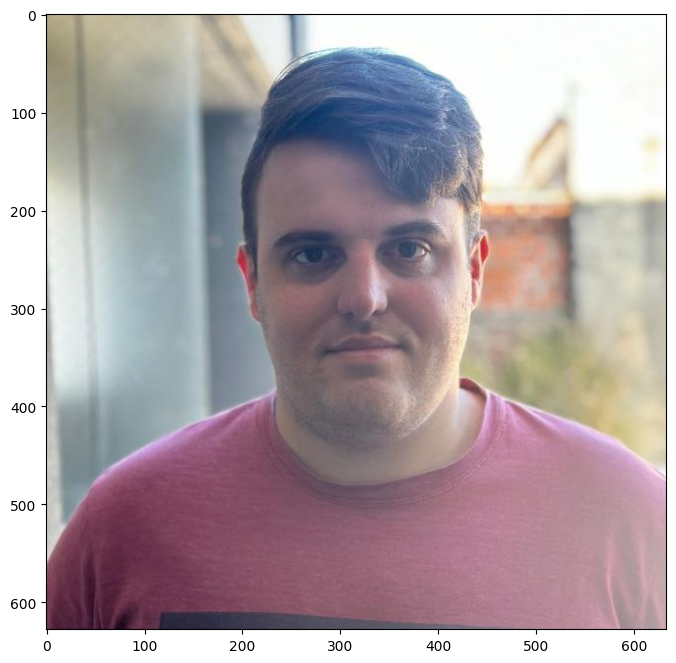

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = personas_dataset['Damian'][0]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

Detected 1 faces
  Face 1: box=[ 293  660  759 1240], confidence=1.000


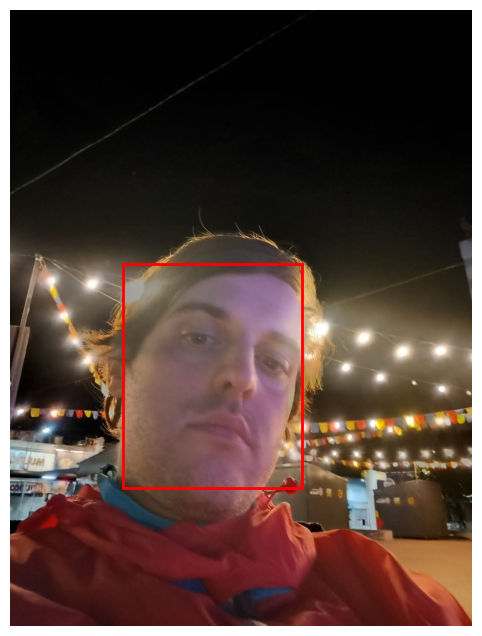

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = personas_dataset['Damian'][1]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

Detected 2 faces
  Face 1: box=[ 298  535  713 1017], confidence=1.000
  Face 2: box=[ 331  979  419 1071], confidence=0.741


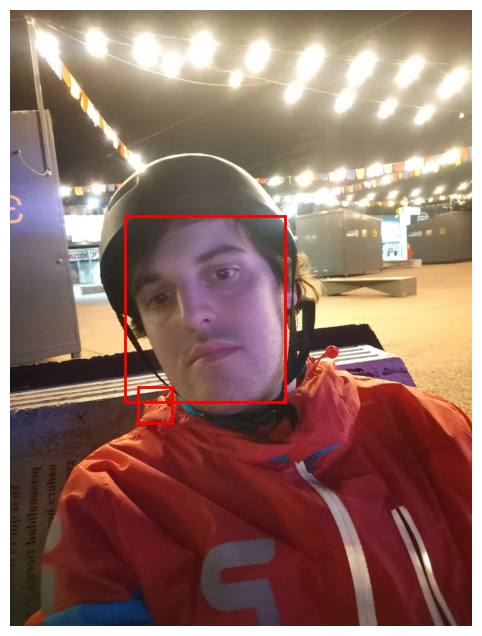

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = personas_dataset['Damian'][2]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()